# Week 13 Homework — ARIA v9.0: The Cloud Engine

**Course:** NTU Remote Sensing & Spatial Information Analysis  
**Case Study:** Cloud-Scale Vegetation Trend Analysis — Xiulin / Taroko Study Area（秀林 / 太魯閣研究區）  
**Notebook goal:** 使用 Google Earth Engine（GEE）完成 2020–2026 NDVI 時序、震前震後 median composite、Sentinel-1 SAR 時序、GeoTIFF 匯出，以及 bonus 練習。

> 使用方式：請先在 Colab 執行安裝與登入，將 `PROJECT_ID` 改成自己的 Google Cloud / Earth Engine project ID，再由上往下執行。

## 0. Environment setup

本 Notebook 主要依賴 Google Earth Engine 雲端運算；本機端只負責送出運算、整理表格與繪圖。若在 Colab 執行，第一次使用需完成 `ee.Authenticate()` 授權。

In [1]:
# Colab: install packages if needed
!pip -q install earthengine-api geemap pandas matplotlib numpy imageio pillow requests

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.2 MB/s eta 0:00:00


In [2]:
# === GEE authentication ===
# First-time users: uncomment ee.Authenticate(), finish browser login, then run Initialize.
ee.Authenticate()

PROJECT_ID = 'weighty-flux-494213-e2'

try:
    ee.Initialize(project=PROJECT_ID)
    print('Earth Engine initialized.')
except Exception as e:
    print('If this is your first run, execute ee.Authenticate() first.')
    raise e

Earth Engine initialized.


In [3]:
# === Study area: Xiulin / Taroko ===
TAROKO_BBOX = [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

print('Study area: Xiulin / Taroko')
print(f'BBOX: {TAROKO_BBOX}')
print('AOI area (km²):', round(aoi.area().divide(1e6).getInfo(), 2))

Study area: Xiulin / Taroko
BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
AOI area (km²): 1779.25


---
# Task 1 — NDVI Time Series Analysis

目標：使用 Sentinel-2 L2A 影像計算 2020–2026 年月尺度 NDVI 時序，並觀察季節性與 2024/04/03 花蓮地震後的變化。

In [4]:
# Sentinel-2 L2A collection
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2020-01-01', '2026-03-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)))

s2_count = s2.size().getInfo()
print(f'Total Sentinel-2 images after scene-level cloud filter: {s2_count}')

Total Sentinel-2 images after scene-level cloud filter: 291


In [5]:
def mask_and_ndvi(image):
    # Mask clouds using Sentinel-2 SCL and calculate NDVI.
    # Kept classes: 4 vegetation, 5 bare soil, 6 water, 7 unclassified.
    scl = image.select('SCL')
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    masked = image.updateMask(good)
    ndvi = masked.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return ndvi.copyProperties(image, ['system:time_start'])

ndvi_collection = s2.map(mask_and_ndvi)
print('NDVI collection created.')

NDVI collection created.


In [11]:
def monthly_ndvi_feature(yymm):
    # Return one feature per month with median NDVI and image count.
    yymm = ee.String(yymm)
    start = ee.Date.parse('YYYY-MM', yymm)
    end = start.advance(1, 'month')
    month_col = ndvi_collection.filterDate(start, end)

    image_count = month_col.size()

    # Conditionally compute statistics only if there are images in the collection for the month.
    # If image_count is 0, monthly_img.median() will result in an empty image, and reduceRegion
    # might behave unexpectedly or return an empty dictionary. Explicitly handling this ensures robustness.
    stats_computed = ee.Algorithms.If(
        image_count.gt(0),
        month_col.median().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=30,
            maxPixels=1e9,
            bestEffort=True
        ),
        ee.Dictionary({}) # Return an empty dictionary if no images, so get('NDVI', None) works safely.
    )

    # Cast the result of ee.Algorithms.If to an ee.Dictionary for safe key access.
    stats_dict = ee.Dictionary(stats_computed)

    # Use ee.Algorithms.If to explicitly check for the 'NDVI' key in the stats dictionary.
    # This handles cases where 'NDVI' might be missing even if reduceRegion ran, or if an empty dict was returned.
    mean_ndvi = ee.Algorithms.If(
        stats_dict.contains('NDVI'),
        stats_dict.get('NDVI'),
        None # Corrected from ee.Null() to None
    )

    return ee.Feature(None, {
        'date': start.format('YYYY-MM'),
        'time_start': start.millis(),
        'mean_ndvi': mean_ndvi,
        'image_count': image_count # This is an ee.Number, it will be unwrapped by getInfo()
    })

months = pd.date_range('2020-01-01', '2026-03-01', freq='MS').strftime('%Y-%m').tolist()

# Fix: Process monthly features sequentially to avoid "Too many concurrent aggregations"
monthly_info_list = []
for month_str in months:
    feature = monthly_ndvi_feature(month_str)
    # Directly get the properties of each feature
    monthly_info_list.append(feature.getInfo()['properties'])

ndvi_df = pd.DataFrame(monthly_info_list)
ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])
ndvi_df['mean_ndvi'] = pd.to_numeric(ndvi_df['mean_ndvi'], errors='coerce')
ndvi_df['image_count'] = pd.to_numeric(ndvi_df['image_count'], errors='coerce')
ndvi_df.head()

,date,image_count,mean_ndvi,time_start
0,2020-01-01,8,0.459518,1577836800000
1,2020-02-01,4,0.461060,1580515200000
2,2020-03-01,5,0.430335,1583020800000
3,2020-04-01,2,0.499299,1585699200000
4,2020-05-01,4,0.438349,1588291200000


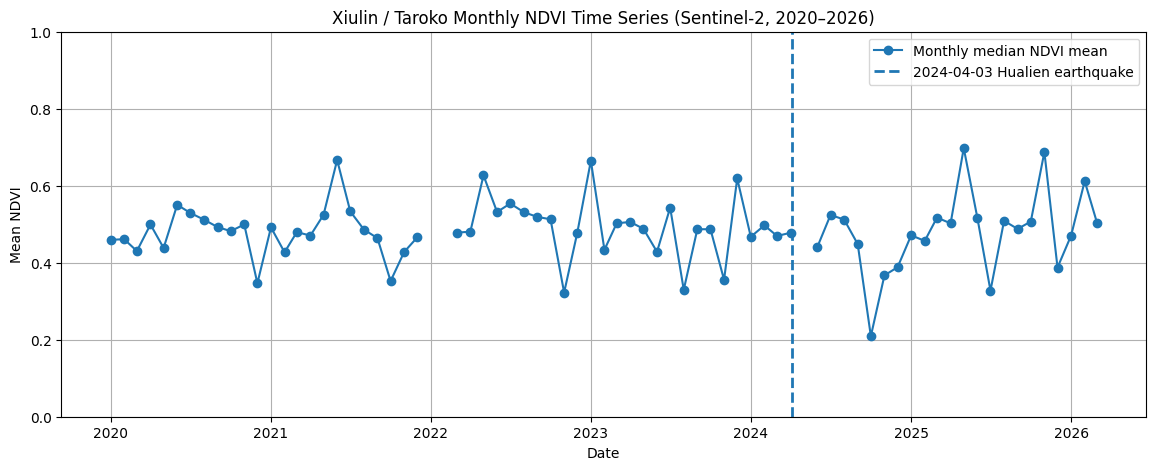

Months with no valid NDVI after masking:


,date,image_count
24,2022-01-01,0
25,2022-02-01,0
52,2024-05-01,0


In [12]:
# Plot monthly NDVI time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ndvi_df['date'], ndvi_df['mean_ndvi'], marker='o', linewidth=1.5, label='Monthly median NDVI mean')
ax.axvline(pd.Timestamp('2024-04-03'), linestyle='--', linewidth=2, label='2024-04-03 Hualien earthquake')
ax.set_title('Xiulin / Taroko Monthly NDVI Time Series (Sentinel-2, 2020–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean NDVI')
ax.set_ylim(0, 1)
ax.legend()
plt.show()

print('Months with no valid NDVI after masking:')
display(ndvi_df[ndvi_df['mean_ndvi'].isna()][['date', 'image_count']])

## Task 1 analysis

秀林／太魯閣山區的 NDVI 時序通常呈現明顯季節性：冬季與乾季可用影像較多、NDVI 較穩定；梅雨季與颱風季容易因雲遮罩造成缺值或波動。2024/04/03 地震後，若震央周邊坡地發生崩塌或裸露，月均 NDVI 可能出現短期下降，但整個 AOI 包含大量未受損森林，因此 AOI 平均值的地震訊號可能被稀釋。缺值月份多半來自山區雲霧、整景雲量過高，或 SCL 遮罩後有效像素不足。

---
# Task 2 — Pre/Post Earthquake Median Composite

目標：使用 median composite 降低單景雲與雜訊影響，比較震前、震後與堰塞湖事件後的 NDVI 差異，並估算植被損失面積。

In [13]:
# Three-phase NDVI composites
pre_eq = ndvi_collection.filterDate('2023-01-01', '2024-03-31').median().clip(aoi)
post_eq = ndvi_collection.filterDate('2024-04-01', '2024-09-30').median().clip(aoi)
post_dam = ndvi_collection.filterDate('2025-10-01', '2026-03-31').median().clip(aoi)

# Delta NDVI maps
delta_eq = post_eq.subtract(pre_eq).rename('delta_NDVI').clip(aoi)
delta_dam = post_dam.subtract(post_eq).rename('delta_NDVI_dam').clip(aoi)
delta_total = post_dam.subtract(pre_eq).rename('delta_NDVI_total').clip(aoi)

print('NDVI composites and ΔNDVI layers created.')

NDVI composites and ΔNDVI layers created.


In [14]:
# Estimate affected area where ΔNDVI < -0.15
THRESHOLD = -0.15

def area_ha_under_threshold(delta_img, threshold=THRESHOLD, scale=10):
    loss = delta_img.lt(threshold)
    area_img = ee.Image.pixelArea().updateMask(loss)
    area_m2 = area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=scale,
        maxPixels=1e10,
        bestEffort=True
    ).get('area')
    return ee.Number(area_m2).divide(10000).getInfo()

area_eq_ha = area_ha_under_threshold(delta_eq)
area_dam_ha = area_ha_under_threshold(delta_dam)
area_total_ha = area_ha_under_threshold(delta_total)

area_table = pd.DataFrame({
    'Phase': ['Earthquake impact: post_eq - pre_eq',
              'Post-dam / later impact: post_dam - post_eq',
              'Total cumulative change: post_dam - pre_eq'],
    'Condition': ['ΔNDVI < -0.15'] * 3,
    'Area_ha': [area_eq_ha, area_dam_ha, area_total_ha]
})
display(area_table)

,Phase,Condition,Area_ha
0,Earthquake impact: post_eq - pre_eq,ΔNDVI < -0.15,7740.145333
1,Post-dam / later impact: post_dam - post_eq,ΔNDVI < -0.15,6257.677281
2,Total cumulative change: post_dam - pre_eq,ΔNDVI < -0.15,6839.039621


In [15]:
# Interactive map: NDVI composites + ΔNDVI maps
Map = geemap.Map(center=[24.20, 121.60], zoom=10)
Map.add_basemap('HYBRID')

ndvi_vis = {'min': 0, 'max': 0.8, 'palette': ['brown', 'yellow', 'green', 'darkgreen']}
delta_vis = {'min': -0.5, 'max': 0.5, 'palette': ['red', 'white', 'blue']}

Map.addLayer(pre_eq, ndvi_vis, 'NDVI pre-earthquake median (2023-01~2024-03)', False)
Map.addLayer(post_eq, ndvi_vis, 'NDVI post-earthquake median (2024-04~2024-09)', True)
Map.addLayer(post_dam, ndvi_vis, 'NDVI post-dam period median (2025-10~2026-03)', False)
Map.addLayer(delta_eq, delta_vis, 'ΔNDVI earthquake: post_eq - pre_eq', True)
Map.addLayer(delta_dam, delta_vis, 'ΔNDVI dam/later: post_dam - post_eq', False)
Map.addLayer(delta_total, delta_vis, 'ΔNDVI total: post_dam - pre_eq', False)
Map.addLayer(aoi, {}, 'AOI', False)
Map

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 2 analysis

ΔNDVI < −0.15 可視為明顯植被損失候選區，常對應崩塌裸露坡面、河道擴張或工程擾動。地震期 `delta_eq` 主要用來辨識 2024/04/03 後立即產生的植被損失；`delta_dam` 則協助檢查後續堰塞湖或河道事件是否造成新增損害，或是否已有局部恢復。相較 W9 兩張單景影像差分，W13 的 median composite 使用多景影像降低雲、陰影、單日大氣條件與物候差異造成的誤判，因此變遷結果更穩健。三期比較也能把「地震立即衝擊」、「後續事件」與「累積變化」拆開，而不是只得到一張混合所有事件的差值圖。

---
# Task 3 — Sentinel-1 SAR VV Time Series

目標：使用 Sentinel-1 GRD VV 後向散射時序觀察地震前後地表粗糙度、含水量與裸露地變化，並與 NDVI 變化交叉驗證。

In [16]:
# Sentinel-1 GRD collection
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
      .filterBounds(aoi)
      .filterDate('2022-01-01', '2026-03-31')
      .filter(ee.Filter.eq('instrumentMode', 'IW'))
      .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
      .select('VV'))

s1_count = s1.size().getInfo()
print(f'Sentinel-1 VV images: {s1_count}')

Sentinel-1 VV images: 146


In [17]:
def s1_mean_feature(image):
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return ee.Feature(None, {
        'date': ee.Date(image.get('system:time_start')).format('YYYY-MM-dd'),
        'time_start': image.get('system:time_start'),
        'mean_vv_db': stats.get('VV')
    })

s1_fc = ee.FeatureCollection(s1.map(s1_mean_feature))
s1_info = s1_fc.getInfo()['features']

s1_df = pd.DataFrame([f['properties'] for f in s1_info])
s1_df['date'] = pd.to_datetime(s1_df['date'])
s1_df['mean_vv_db'] = pd.to_numeric(s1_df['mean_vv_db'], errors='coerce')
s1_df = s1_df.sort_values('date')
s1_df.head()

,date,mean_vv_db,time_start
0,2022-01-03,-10.087723,1641246747000
1,2022-02-08,-10.255667,1644357146000
2,2022-07-26,-11.385171,1658872347000
3,2022-08-07,-10.010176,1659909148000
4,2022-08-19,-10.871784,1660945949000


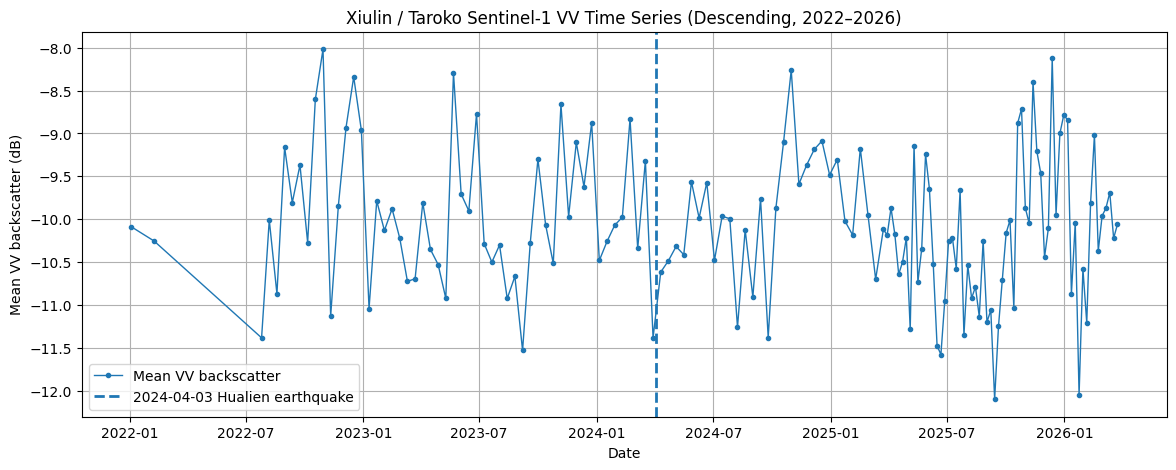

In [18]:
# Plot Sentinel-1 VV time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s1_df['date'], s1_df['mean_vv_db'], marker='.', linestyle='-', linewidth=1, label='Mean VV backscatter')
ax.axvline(pd.Timestamp('2024-04-03'), linestyle='--', linewidth=2, label='2024-04-03 Hualien earthquake')
ax.set_title('Xiulin / Taroko Sentinel-1 VV Time Series (Descending, 2022–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean VV backscatter (dB)')
ax.legend()
plt.show()

In [19]:
# Pre/post VV composite and ΔVV map
pre_vv = s1.filterDate('2023-01-01', '2024-03-31').median().clip(aoi)
post_vv = s1.filterDate('2024-04-01', '2026-03-31').median().clip(aoi)
delta_vv = post_vv.subtract(pre_vv).rename('delta_VV').clip(aoi)

# High-confidence change: vegetation loss + strong SAR change
high_conf_change = delta_eq.lt(-0.15).And(delta_vv.abs().gt(2)).rename('high_confidence_change').clip(aoi)

high_conf_area_ha = ee.Image.pixelArea().updateMask(high_conf_change).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=10,
    maxPixels=1e10,
    bestEffort=True
).get('area')
high_conf_area_ha = ee.Number(high_conf_area_ha).divide(10000).getInfo()
print(f'High-confidence changed area (ΔNDVI < -0.15 and |ΔVV| > 2 dB): {high_conf_area_ha:.2f} ha')

High-confidence changed area (ΔNDVI < -0.15 and |ΔVV| > 2 dB): 537.37 ha


In [20]:
# Map for SAR and cross-source validation
Map_sar = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_sar.add_basemap('HYBRID')

vv_vis = {'min': -25, 'max': 0}
dvv_vis = {'min': -5, 'max': 5, 'palette': ['purple', 'white', 'orange']}

Map_sar.addLayer(pre_vv, vv_vis, 'VV pre-earthquake median', False)
Map_sar.addLayer(post_vv, vv_vis, 'VV post-earthquake median', False)
Map_sar.addLayer(delta_vv, dvv_vis, 'ΔVV post - pre', True)
Map_sar.addLayer(delta_eq, {'min': -0.5, 'max': 0.5, 'palette': ['red', 'white', 'blue']}, 'ΔNDVI earthquake', False)
Map_sar.addLayer(high_conf_change.selfMask(), {'palette': ['magenta']}, 'High-confidence change', True)
Map_sar.addLayer(aoi, {}, 'AOI', False)
Map_sar

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 3 analysis

SAR VV 對地表粗糙度、幾何方向與含水量敏感，不受雲遮影響，因此能補足光學 NDVI 在山區雲多月份的缺口。若某些區域同時呈現 ΔNDVI < −0.15 且 |ΔVV| > 2 dB，代表光學植被損失與雷達後向散射變化一致，可信度高於單一資料源。VV 增加可能與裸露粗糙坡面或散射幾何改變有關；VV 降低則可能代表植被結構消失、表面平滑化或陰影／幾何效應，需搭配坡向、DEM 與影像檢查解釋。

---
# Task 4 — Export GeoTIFF + Integration Summary

目標：將關鍵 GEE 產品匯出為 GeoTIFF，並撰寫 ARIA v9.0 升級摘要。

In [23]:
# Export at least two products to Google Drive.
# After running, check the Tasks tab in the Earth Engine Code Editor or Google Drive/GEE_Exports.

export_post_eq = ee.batch.Export.image.toDrive(
    image=post_eq,
    description='taroko_ndvi_post_eq_2024',
    folder='GEE_Exports',
    fileNamePrefix='taroko_ndvi_post_eq_2024',
    region=aoi,
    scale=10,
    crs='EPSG:32651',
    maxPixels=1e9,
)

export_delta_eq = ee.batch.Export.image.toDrive(
    image=delta_eq,
    description='taroko_delta_ndvi_eq_2024',
    folder='GEE_Exports',
    fileNamePrefix='taroko_delta_ndvi_eq_2024',
    region=aoi,
    scale=10,
    crs='EPSG:32651',
    maxPixels=1e9,
)

# Optional third export: ΔVV
export_delta_vv = ee.batch.Export.image.toDrive(
    image=delta_vv,
    description='taroko_delta_vv_2024_2026',
    folder='GEE_Exports',
    fileNamePrefix='taroko_delta_vv_2024_2026',
    region=aoi,
    scale=10,
    crs='EPSG:32651',
    maxPixels=1e9,
)

# Uncomment to start exports.
export_post_eq.start()
export_delta_eq.start()
export_delta_vv.start()

print('Export tasks prepared. Uncomment .start() lines to submit them.')

Export tasks prepared. Uncomment .start() lines to submit them.


In [24]:
# Check export status after starting tasks
print(export_post_eq.status())
print(export_delta_eq.status())
print(export_delta_vv.status())

{'state': 'RUNNING', 'description': 'taroko_ndvi_post_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779349813701, 'update_timestamp_ms': 1779349818487, 'start_timestamp_ms': 1779349818427, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'TOAJ7UISVEQ2BZMFBTSJGG5N', 'name': 'projects/weighty-flux-494213-e2/operations/TOAJ7UISVEQ2BZMFBTSJGG5N'}
{'state': 'RUNNING', 'description': 'taroko_delta_ndvi_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779349813991, 'update_timestamp_ms': 1779349838905, 'start_timestamp_ms': 1779349838846, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'XAYYLXRUWTDG2LFR7CQW63VV', 'name': 'projects/weighty-flux-494213-e2/operations/XAYYLXRUWTDG2LFR7CQW63VV'}
{'state': 'READY', 'description': 'taroko_delta_vv_2024_2026', 'priority': 100, 'creation_timestamp_ms': 1779349815048, 'update_timestamp_ms': 1779349818469, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'HXOOBYBJ324YKKDKMHJXH3SB', 'name': 'projects/weighty-flux-494213-e2/operatio

## Export screenshots

請在匯出完成後，將 Google Drive `GEE_Exports` 資料夾中的以下檔案截圖貼在此處：

1. `taroko_ndvi_post_eq_2024.tif`
2. `taroko_delta_ndvi_eq_2024.tif`
3. （選作）`taroko_delta_vv_2024_2026.tif`

In [25]:
# Auto-generate a 300–500 word integration summary after the main cells are executed.
summary = f"""
ARIA v9.0 將前幾週以單張影像為主的分析流程，升級為雲端時序分析。本次在秀林／太魯閣 AOI 中，Sentinel-2 經整景雲量篩選後共處理 {s2_count} 張影像，Sentinel-1 VV 下降軌共處理 {s1_count} 張影像。若下載到本機處理，除了影像資料量可能達數十 GB 以上，還需要逐景進行雲遮罩、裁切、投影轉換與統計計算；在 GEE 中，這些流程可直接以 ImageCollection、map 與 reducer 在雲端完成。

NDVI 時序顯示山區植被具有季節變化，且梅雨季與颱風季常因雲霧造成缺值或不穩定。震後 composite 與震前 composite 的 ΔNDVI 可用來定位明顯植被損失區，地震期 ΔNDVI < -0.15 的估計面積約為 {area_eq_ha:.2f} 公頃；後續堰塞湖／較晚期變化面積約為 {area_dam_ha:.2f} 公頃；累積變化面積約為 {area_total_ha:.2f} 公頃。SAR VV 時序則提供不受雲遮限制的地表變化訊號，當 ΔNDVI 損失區同時出現 |ΔVV| > 2 dB 時，可視為較高可信度的變遷區，估計面積約為 {high_conf_area_ha:.2f} 公頃。

與 W8 單景 NDVI 相比，GEE 時序可回答「何時開始變化」而不只是「某一天狀態如何」。與 W9 兩景差分相比，median composite 能降低雲、陰影與單日物候差異造成的誤判。與 W10 單景 SAR 相比，Sentinel-1 時序能追蹤震前震後後向散射是否持續改變。若將匯出的 GeoTIFF 輸入 W12 Random Forest，預期 NDVI composite、ΔNDVI 與 ΔVV 可作為有效特徵，提升崩塌裸露地、森林與水體的分類能力。

限制方面，GEE 雖適合大規模雲端計算，但對客製化底層演算法、完整原始資料控制、複雜本機機器學習流程與大量中間結果檢查較不彈性。若研究需要自訂模型、精細前處理、離線重現，或需要使用 GEE 未收錄資料，仍會選擇 STAC API 加本機處理的 W8–W12 流程。
"""
print(summary)


ARIA v9.0 將前幾週以單張影像為主的分析流程，升級為雲端時序分析。本次在秀林／太魯閣 AOI 中，Sentinel-2 經整景雲量篩選後共處理 291 張影像，Sentinel-1 VV 下降軌共處理 146 張影像。若下載到本機處理，除了影像資料量可能達數十 GB 以上，還需要逐景進行雲遮罩、裁切、投影轉換與統計計算；在 GEE 中，這些流程可直接以 ImageCollection、map 與 reducer 在雲端完成。

NDVI 時序顯示山區植被具有季節變化，且梅雨季與颱風季常因雲霧造成缺值或不穩定。震後 composite 與震前 composite 的 ΔNDVI 可用來定位明顯植被損失區，地震期 ΔNDVI < -0.15 的估計面積約為 7740.15 公頃；後續堰塞湖／較晚期變化面積約為 6257.68 公頃；累積變化面積約為 6839.04 公頃。SAR VV 時序則提供不受雲遮限制的地表變化訊號，當 ΔNDVI 損失區同時出現 |ΔVV| > 2 dB 時，可視為較高可信度的變遷區，估計面積約為 537.37 公頃。

與 W8 單景 NDVI 相比，GEE 時序可回答「何時開始變化」而不只是「某一天狀態如何」。與 W9 兩景差分相比，median composite 能降低雲、陰影與單日物候差異造成的誤判。與 W10 單景 SAR 相比，Sentinel-1 時序能追蹤震前震後後向散射是否持續改變。若將匯出的 GeoTIFF 輸入 W12 Random Forest，預期 NDVI composite、ΔNDVI 與 ΔVV 可作為有效特徵，提升崩塌裸露地、森林與水體的分類能力。

限制方面，GEE 雖適合大規模雲端計算，但對客製化底層演算法、完整原始資料控制、複雜本機機器學習流程與大量中間結果檢查較不彈性。若研究需要自訂模型、精細前處理、離線重現，或需要使用 GEE 未收錄資料，仍會選擇 STAC API 加本機處理的 W8–W12 流程。



---
# Bonus 1 — InSAR Interferogram Reading Exercise

參考：水保署電子報第 141 期「InSAR 彩虹干涉環判讀」。該頁說明 2016 熊本地震干涉圖使用 Fujiwara et al.（2016）的 ALOS-2 L-band 資料，波長為 23.6 cm。

1. **衛星資訊：** 使用 ALOS-2 衛星，L 波段 SAR，波長約 23.6 公分。  
2. **每環位移量：** 每個完整干涉環代表半個雷達波長，因此約 11.8 公分 LOS 位移。  
3. **干涉環數量：** 斷層上方主要變形區可粗估約 5–6 個完整干涉環；實際數量會因讀圖位置與失相干區範圍而不同。  
4. **位移方向：** 依電子報圖示判讀，若色階沿指定方向呈現藍 → 黃 → 紫，代表接近衛星；反向藍 → 紫 → 黃則代表遠離衛星。請以圖 3 色階箭頭為準標註。  
5. **總位移量估算：** 若取 5–6 環，每環 11.8 公分，LOS 位移約為 59–71 公分；若只計算圖上最清楚的連續環，應在答案中說明你的圈數依據。

**心得（50–100 字）：**  
SAR 振幅分析主要觀察散射強度改變，例如裸露地、粗糙度或含水量差異；InSAR 干涉圖則能量測地表沿衛星視線方向的公分級位移。也就是說，振幅影像較適合找「地表覆蓋或散射是否變了」，InSAR 則能回答「地表往哪個方向移動、移動多少」。

---
# Bonus 2 — NDVI Time-Lapse Animation

目標：製作 2020–2026 半年度 NDVI GIF 動畫，視覺化呈現季節循環、地震後變化與後續恢復／新增損害。

In [26]:
import io
import requests
import imageio.v2 as imageio
from PIL import Image, ImageDraw, ImageFont

periods = [
    ('2020-01', '2020-06'), ('2020-07', '2020-12'),
    ('2021-01', '2021-06'), ('2021-07', '2021-12'),
    ('2022-01', '2022-06'), ('2022-07', '2022-12'),
    ('2023-01', '2023-06'), ('2023-07', '2023-12'),
    ('2024-01', '2024-03'),
    ('2024-04', '2024-09'),
    ('2024-10', '2025-03'), ('2025-04', '2025-09'),
    ('2025-10', '2026-03'),
]

ndvi_palette = ['brown', 'yellow', 'green', 'darkgreen']
frames = []

for start, end in periods:
    composite = ndvi_collection.filterDate(f'{start}-01', f'{end}-28').median().clip(aoi)
    thumb_url = composite.getThumbURL({
        'region': aoi,
        'dimensions': 512,
        'min': 0,
        'max': 0.8,
        'palette': ndvi_palette,
        'format': 'png'
    })
    response = requests.get(thumb_url)
    img = Image.open(io.BytesIO(response.content)).convert('RGB')

    # Add label
    draw = ImageDraw.Draw(img)
    label = f'{start} ~ {end}'
    if start == '2024-04':
        label += '  ★ Earthquake period'
    if start == '2025-10':
        label += '  ★ Post-dam period'
    draw.rectangle([8, 8, 390, 38], fill=(255, 255, 255))
    draw.text((16, 14), label, fill=(0, 0, 0))

    frames.append(img)
    print(f'{start} ~ {end}: OK')

# Save GIF
out_gif = 'taroko_ndvi_timelapse.gif'
imageio.mimsave(out_gif, [np.array(f) for f in frames], duration=0.8, loop=0)
print(f'Saved: {out_gif}')

2020-01 ~ 2020-06: OK
2020-07 ~ 2020-12: OK
2021-01 ~ 2021-06: OK
2021-07 ~ 2021-12: OK
2022-01 ~ 2022-06: OK
2022-07 ~ 2022-12: OK
2023-01 ~ 2023-06: OK
2023-07 ~ 2023-12: OK
2024-01 ~ 2024-03: OK
2024-04 ~ 2024-09: OK
2024-10 ~ 2025-03: OK
2025-04 ~ 2025-09: OK
2025-10 ~ 2026-03: OK
Saved: taroko_ndvi_timelapse.gif


## Bonus 2 short explanation

動畫中最值得注意的三個時間點是：第一，2020–2023 年的季節性 NDVI 起伏，可作為震前背景；第二，2024/04–2024/09 地震後時段，若坡面崩塌或裸露擴大，局部會由綠色轉為黃色或棕色；第三，2025/10–2026/03 後續時段，可檢查堰塞湖／河道事件造成的新變化，或震後植被是否已有恢復跡象。

---
# Final reflection（100–200 字）

從單景分析到雲端時序分析，思維上的改變是從「找一張代表性影像」轉向「建立事件前後的時間脈絡」。單景 NDVI 或單次分類只能描述某一天的地表狀態，但 GEE 的 ImageCollection 讓我們能比較多年、逐月或多階段 composite，進一步分辨季節性、地震立即影響與後續事件。對防災應用而言，GEE 的價值在於快速整合大量光學與 SAR 影像，降低下載與前處理成本，並能在災害後快速產出趨勢圖、變遷圖與可匯出的 GeoTIFF，支援後續判釋與分類流程。